In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
import matplotlib.pyplot as plt


home = os.environ.get("HOME")
if not home:
    raise RuntimeError("HOME env not set.")
input_dir = Path(home) / "Projects/Masterarbeit/simdata"
input_file_path = input_dir / "grid_search_data.jsonl"

jsonObj = pd.read_json(path_or_buf= input_file_path, lines=True)

print(len(jsonObj))





626


In [34]:
jsonObj

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.5,0.5,0.10,0.10,0
1,115.226635,0.5,0.5,0.35,0.10,1
2,115.249227,0.5,0.5,0.60,0.10,2
3,115.273805,0.5,0.5,0.85,0.10,3
4,115.296531,0.5,0.5,1.10,0.10,4
...,...,...,...,...,...,...
621,117.061801,1.5,1.5,1.10,0.85,619
622,117.389628,1.5,1.5,0.10,1.10,620
623,117.428541,1.5,1.5,0.60,1.10,622
624,117.447672,1.5,1.5,0.85,1.10,623


In [35]:
jsonObj["turn"].nunique()


621

In [36]:
counts =jsonObj["turn"].value_counts()
jsonObj[jsonObj["turn"].duplicated(keep=False)].sort_values("turn")

,angle,glenohumeral_roll_joint,glenohumeral_yaw_joint,sternoclavicular_pitch_joint,sternoclavicular_yaw_joint,turn
0,115.204076,0.5,0.5,0.10,0.1,0
5,115.212058,0.5,0.5,0.10,0.1,0
1,115.226635,0.5,0.5,0.35,0.1,1
6,115.234604,0.5,0.5,0.35,0.1,1
2,115.249227,0.5,0.5,0.60,0.1,2
7,115.257212,0.5,0.5,0.60,0.1,2
3,115.273805,0.5,0.5,0.85,0.1,3
8,115.279801,0.5,0.5,0.85,0.1,3
4,115.296531,0.5,0.5,1.10,0.1,4
9,115.302316,0.5,0.5,1.10,0.1,4


In [37]:
missing = pd.Index(range(625)).difference(jsonObj["turn"])
missing

Index([210, 472, 530, 621], dtype='int64')

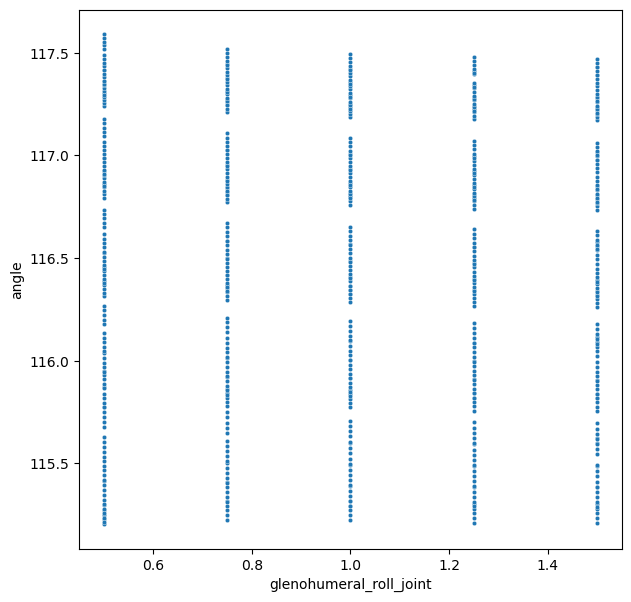

In [38]:
fig, ax1 = plt.subplots(1, 1, figsize=(7,7))
sns.scatterplot(jsonObj, x="glenohumeral_roll_joint", y="angle", ax=ax1, s=10)
plt.show()



/tmp/ipykernel_28493/2988026740.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


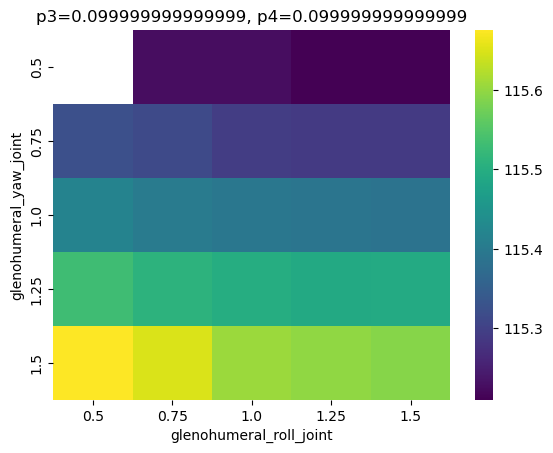

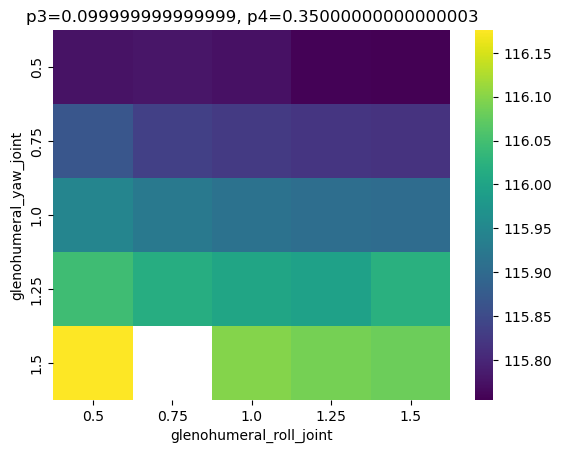

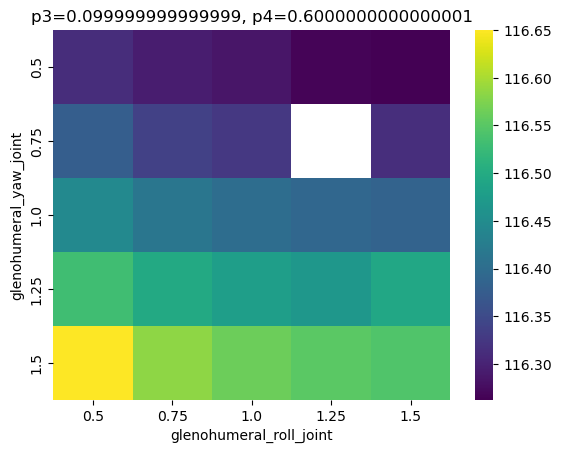

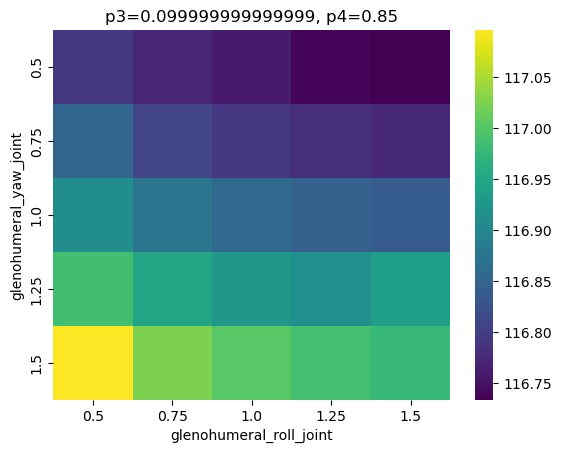

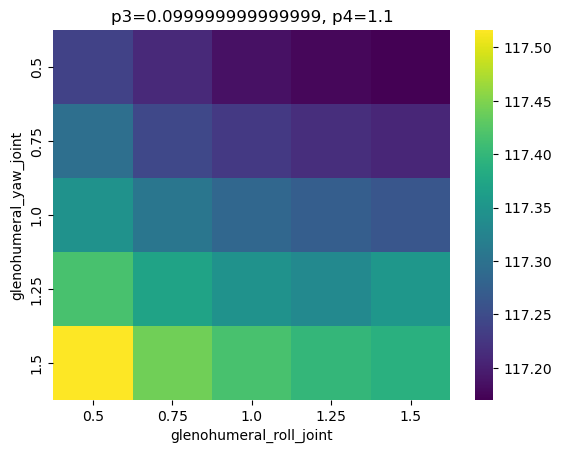

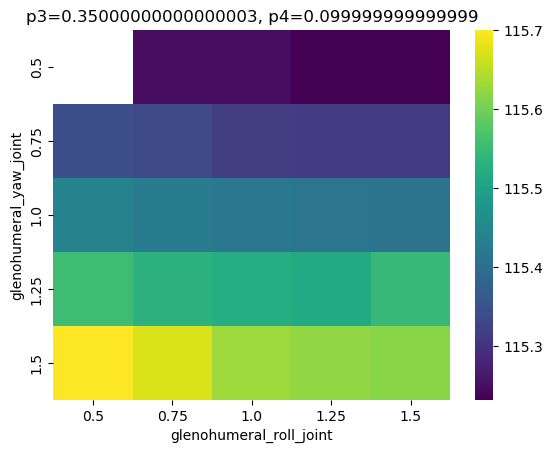

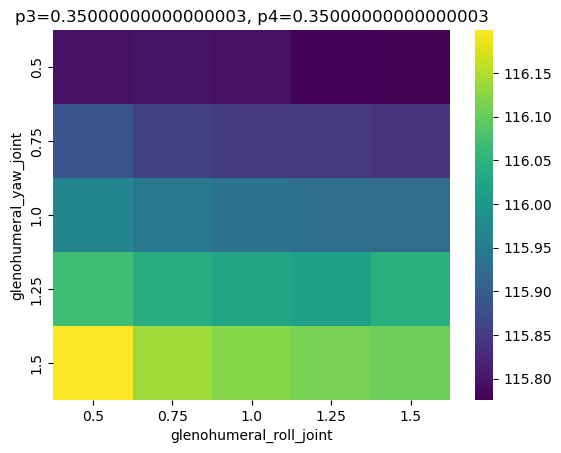

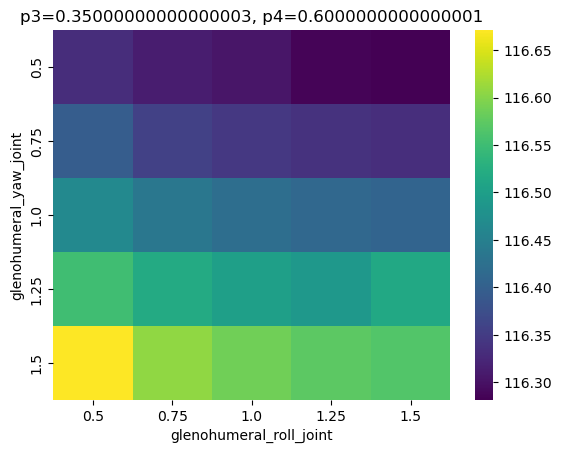

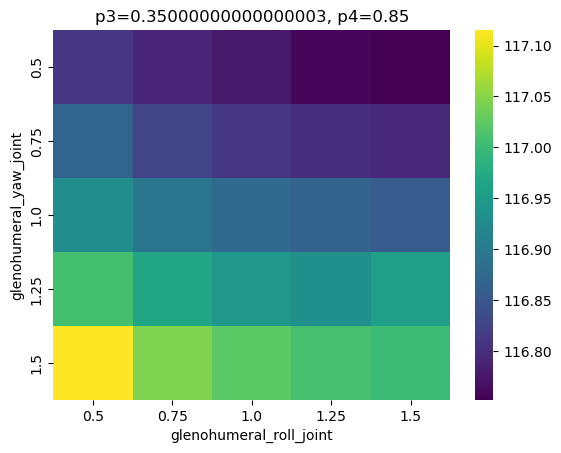

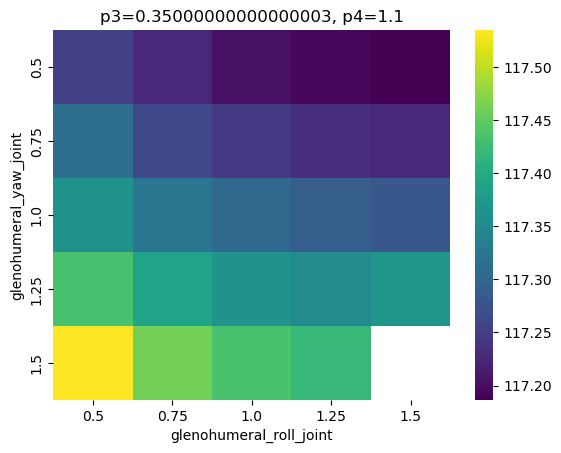

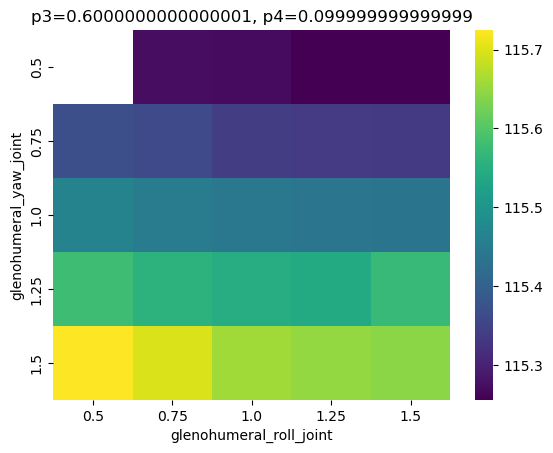

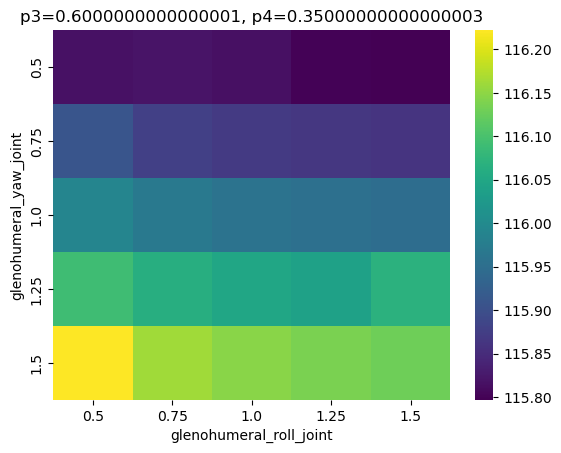

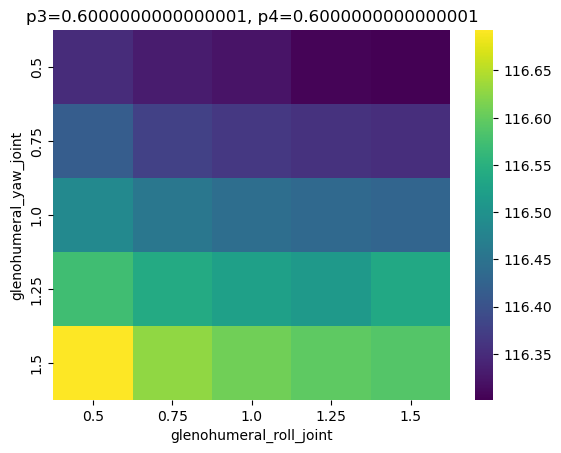

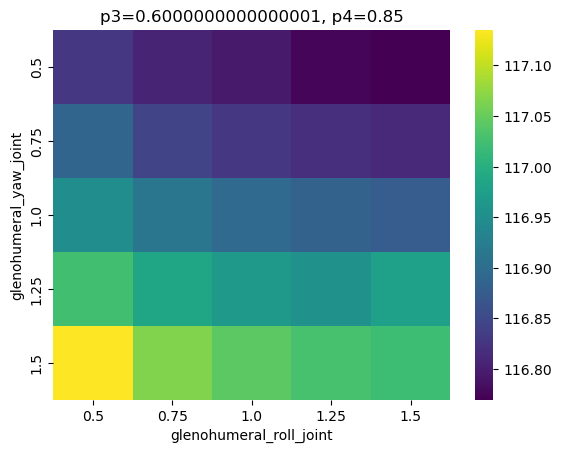

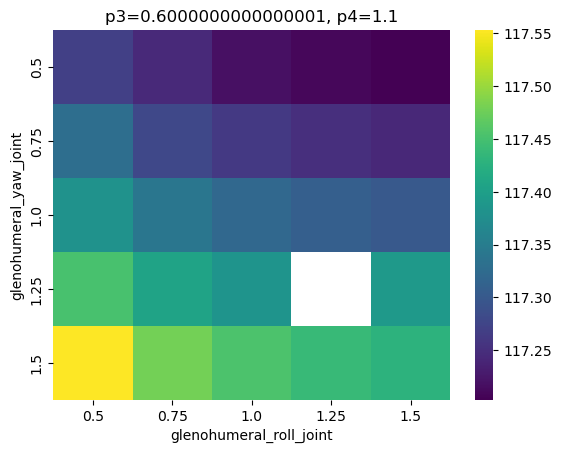

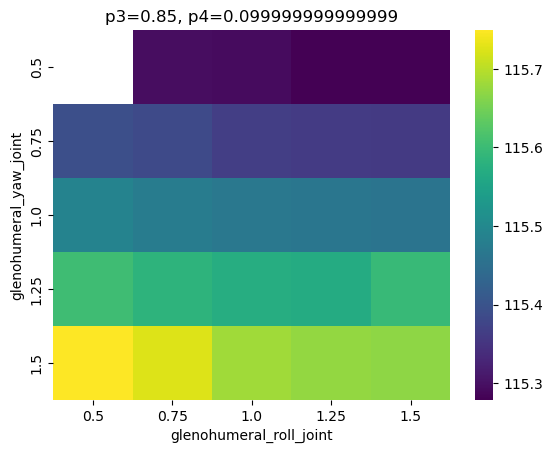

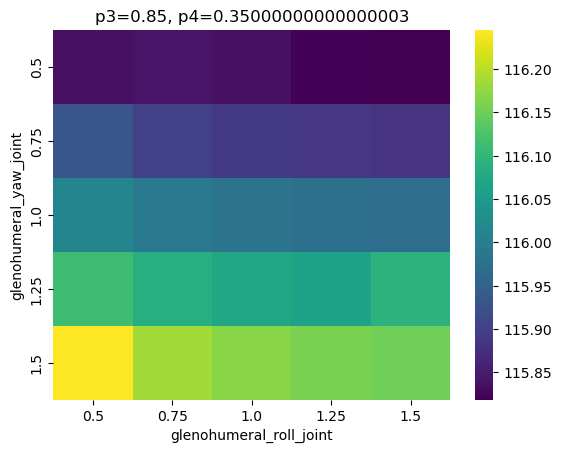

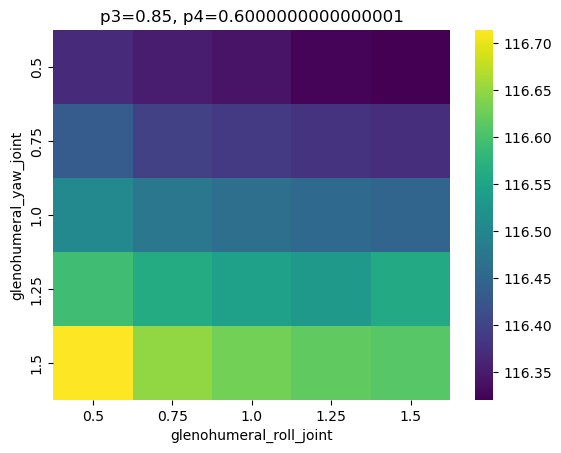

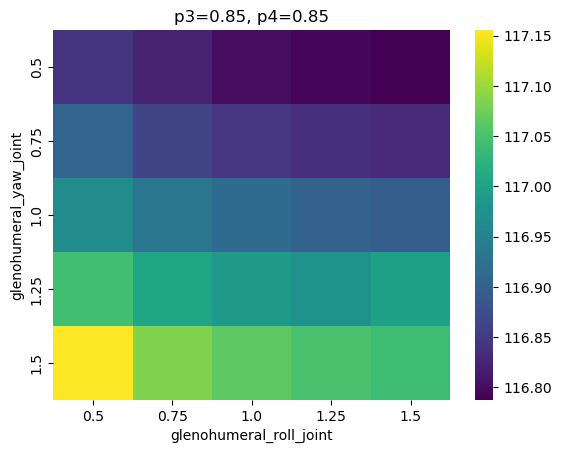

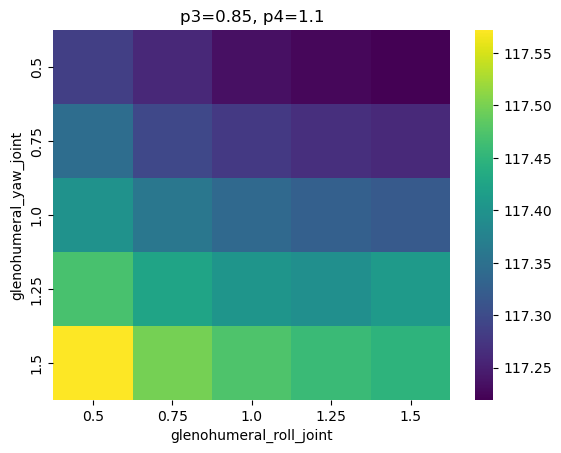

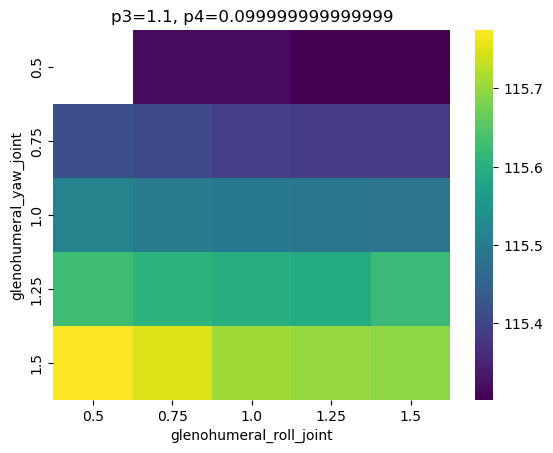

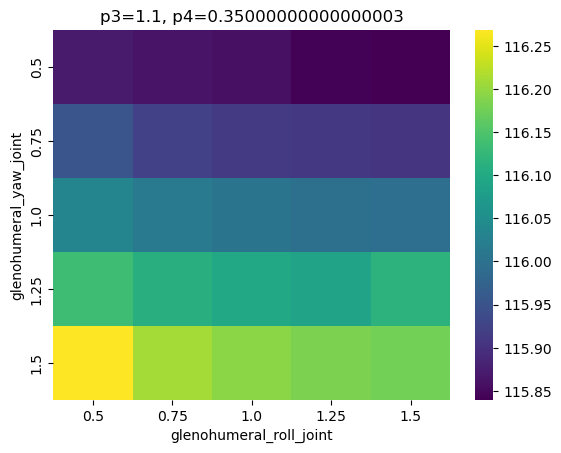

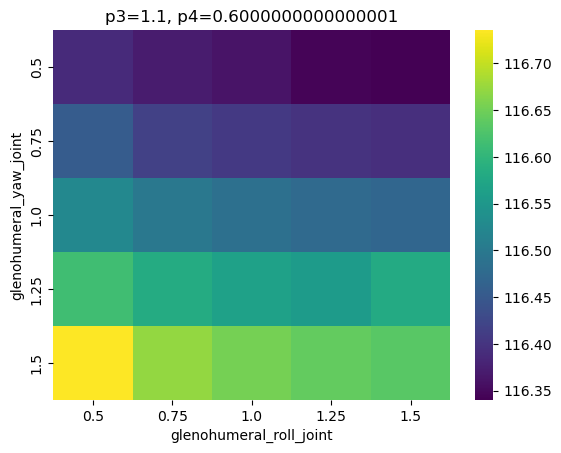

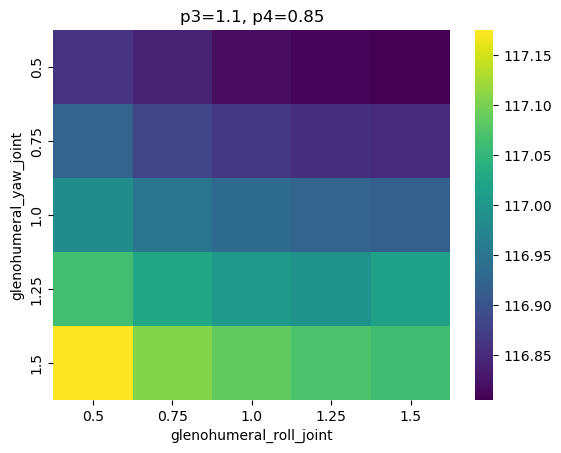

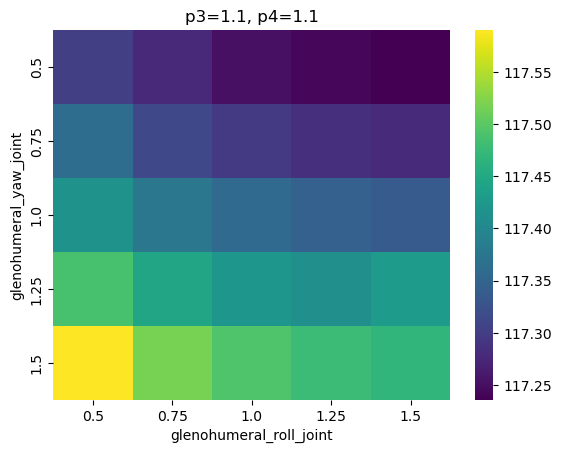

In [ ]:
# p1= "glenohumeral_roll_joint"
# p2= "glenohumeral_yaw_joint"
# p3= "sternoclavicular_pitch_joint"
# p4= "sternoclavicular_yaw_joint"

# jsonObj = jsonObj.iloc[5:].reset_index(drop=True)


# for (p3, p4), sub in jsonObj.groupby([p3, p4]):
#     pivot = sub.pivot(index=p2, columns=p1, values="angle")
    
#     plt.figure()
#     sns.heatmap(pivot, annot=False, cmap="viridis")
#     plt.title(f"p3={p3}, p4={p4}")
#     plt.xlabel(p1)
#     plt.ylabel(p2)
#     plt.show()

In [53]:
best = jsonObj.loc[jsonObj["angle"].idxmin()]
print(best)

angle                           115.209738
glenohumeral_roll_joint           1.500000
glenohumeral_yaw_joint            0.500000
sternoclavicular_pitch_joint      0.100000
sternoclavicular_yaw_joint        0.100000
turn                            100.000000
Name: 95, dtype: float64


In [54]:
top = jsonObj.nsmallest(10, "angle")
print(top)

         angle  glenohumeral_roll_joint  glenohumeral_yaw_joint  \
95  115.209738                     1.50                     0.5   
70  115.210092                     1.25                     0.5   
45  115.224534                     1.00                     0.5   
20  115.225568                     0.75                     0.5   
96  115.232814                     1.50                     0.5   
71  115.233440                     1.25                     0.5   
46  115.247591                     1.00                     0.5   
21  115.248290                     0.75                     0.5   
97  115.256069                     1.50                     0.5   
72  115.256411                     1.25                     0.5   

    sternoclavicular_pitch_joint  sternoclavicular_yaw_joint  turn  
95                          0.10                         0.1   100  
70                          0.10                         0.1    75  
45                          0.10                       

<AxesSubplot: xlabel='glenohumeral_roll_joint', ylabel='sternoclavicular_pitch_joint'>

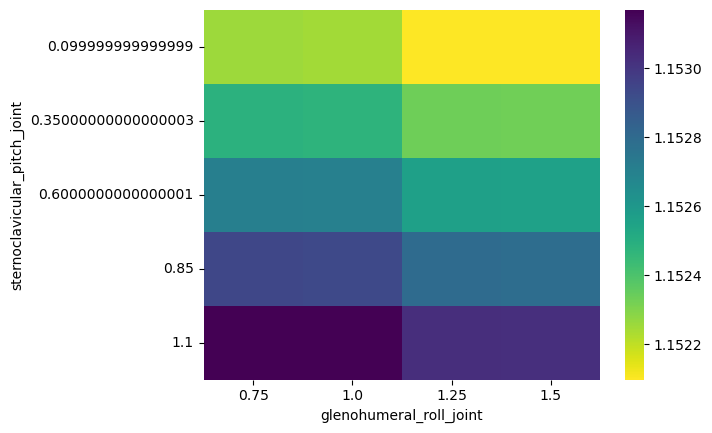

In [64]:
reduced = jsonObj[
    np.isclose(jsonObj["glenohumeral_yaw_joint"], 0.5) &
    np.isclose(jsonObj["sternoclavicular_yaw_joint"], 0.1)
]
reduced = reduced.copy()
reduced["angle"] = reduced["angle"] / 100
pivot = reduced.pivot_table(
    index="sternoclavicular_pitch_joint",
    columns="glenohumeral_roll_joint",
    values="angle",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="viridis_r")